In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:

import argparse
import time
import numpy as np
from sklearn.datasets import make_blobs

import hdbscan


from core_sg import CoreSGClusterer

In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [4]:
def scatter_labels(ax, X_plot, labels, title):
    unique_labels = np.unique(labels)

    non_noise_labels = [lab for lab in unique_labels if lab != -1]
    cmap = plt.cm.get_cmap("tab20", max(1, len(non_noise_labels)))
    color_map = {lab: cmap(i) for i, lab in enumerate(non_noise_labels)}

    for lab in unique_labels:
        mask = labels == lab

        if lab == -1:
            ax.scatter(
                X_plot[mask, 0],
                X_plot[mask, 1],
                label="noise (-1)",
                alpha=0.8,
                marker="x",
                s=40,
                c="black",
            )
        else:
            ax.scatter(
                X_plot[mask, 0],
                X_plot[mask, 1],
                label=f"cluster {lab}",
                alpha=0.8,
                s=30,
                c=[color_map[lab]],
            )

    ax.set_title(title)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.legend(loc="best", fontsize=8)

In [5]:
n = 15000
d = 2
centers = 10
k = 30
seed = 42
atol = 1e-12
rtol = 1e-9

print(f"Generating synthetic dataset: n={n}, d={d}, centers={centers}, seed={seed}")
X, _ = make_blobs(
    n_samples=n,
    n_features=d,
    centers=centers,
    random_state=seed)

Generating synthetic dataset: n=15000, d=2, centers=10, seed=42


# Building Core-SG

In [6]:
# --- Build Core-SG (calculando pairwise dentro) ---
t0 = time.time()
core_sg_clusterer = CoreSGClusterer(k_max=k, metric="euclidean", p=2, verbose=1, no_noise=False, match_reference_implementation=True)
core_sg_clusterer.fit(X, k=k)
core_sg_ = core_sg_clusterer.core_sg_
build_core_sg_time = time.time() - t0
print(f"Core-SG build time (k={k}): {build_core_sg_time:.4f}s")


Core-SG build done in 35.36s
Core-SG build time (k=30): 35.3570s


/tmp/ipykernel_21106/2601943662.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, len(non_noise_labels)))


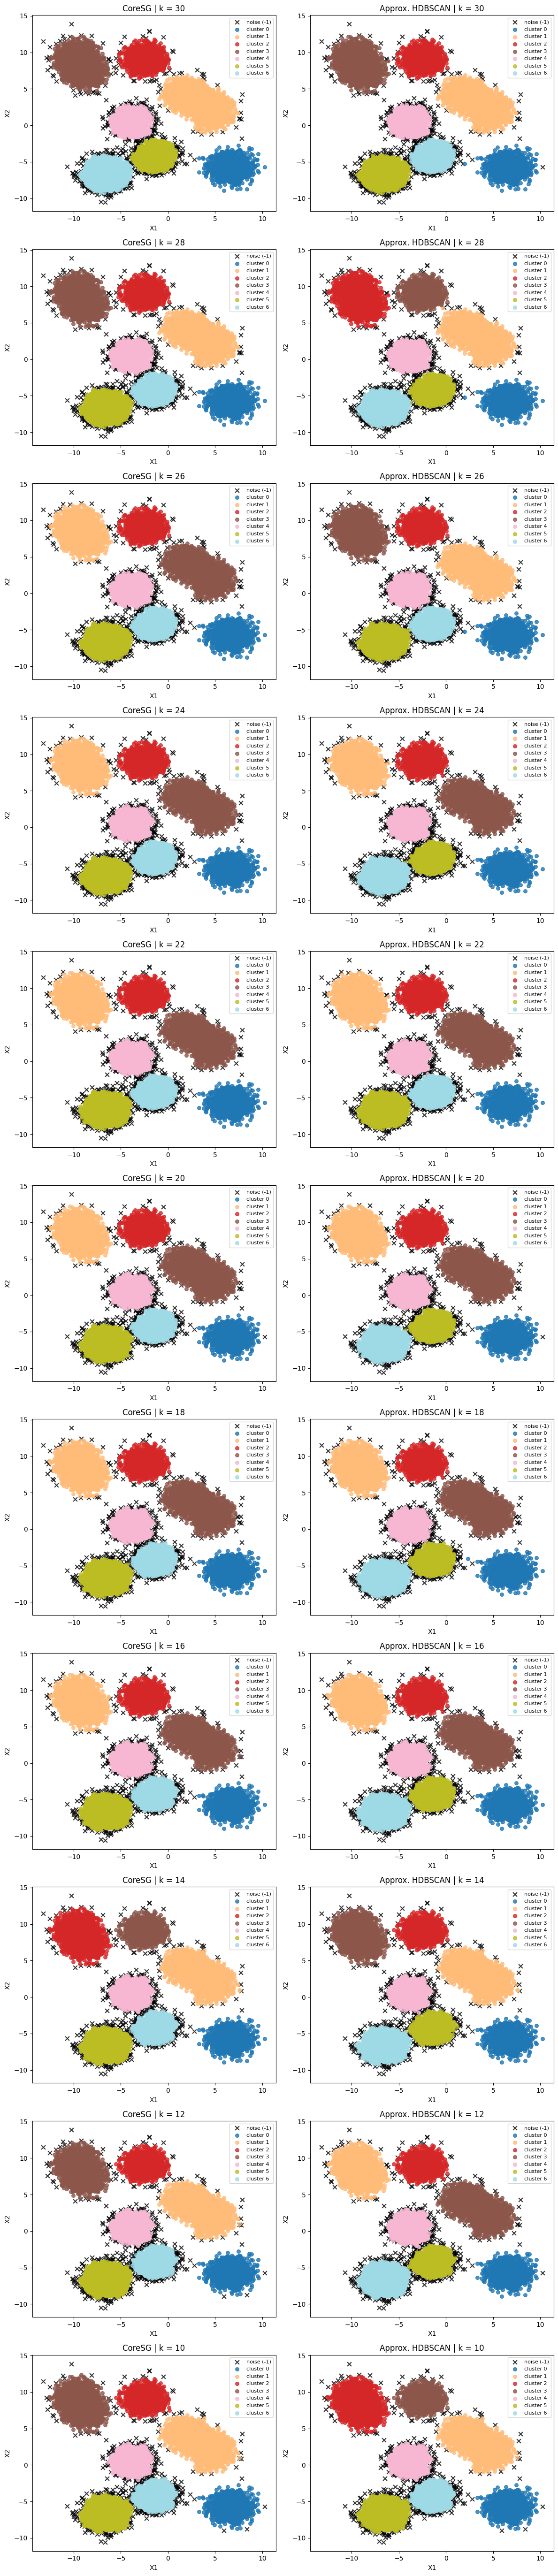

{30: {'core_sg': 35.357046365737915, 'approx_hdbscan': 0.48189687728881836},
 28: {'core_sg': 1.7125136852264404, 'approx_hdbscan': 0.4611833095550537},
 26: {'core_sg': 1.7253048419952393, 'approx_hdbscan': 0.4334743022918701},
 24: {'core_sg': 1.7344448566436768, 'approx_hdbscan': 0.4922459125518799},
 22: {'core_sg': 1.763564109802246, 'approx_hdbscan': 0.4981980323791504},
 20: {'core_sg': 1.7916581630706787, 'approx_hdbscan': 0.4584214687347412},
 18: {'core_sg': 1.818838119506836, 'approx_hdbscan': 0.4633214473724365},
 16: {'core_sg': 1.7834372520446777, 'approx_hdbscan': 0.4623069763183594},
 14: {'core_sg': 1.7513773441314697, 'approx_hdbscan': 0.4158444404602051},
 12: {'core_sg': 1.7982330322265625, 'approx_hdbscan': 0.4575204849243164},
 10: {'core_sg': 1.894782543182373, 'approx_hdbscan': 0.5002741813659668}}

In [7]:
import math
import matplotlib.pyplot as plt
import numpy as np

from hdbscan import HDBSCAN

results = []
d = {}
d[k] = {"core_sg": build_core_sg_time, "approx_hdbscan": 0.0}

core_sg_.set_verbose(False)

for k_iter in range(k, 8, -2):
    if k_iter not in d:
        d[k_iter] = {"core_sg": 0.0, "approx_hdbscan": 0.0}

    # Core-SG
    t0 = time.time()
    core_sg_.extract_hierarchy_from_core_sg(k_iter)
    d[k_iter]["core_sg"] += time.time() - t0
    labels_core_sg = core_sg_.labels_.copy()

    # Approximate HDBSCAN
    t0 = time.time()
    hdb = HDBSCAN(
        min_cluster_size=k_iter,
        min_samples=k_iter,
        metric="euclidean",
        algorithm='best',
        approx_min_span_tree=False,
        gen_min_span_tree=True,
    ).fit(X)
    d[k_iter]["approx_hdbscan"] += time.time() - t0
    labels_hdbscan = hdb.labels_

    results.append((k_iter, labels_core_sg, labels_hdbscan))

n_plots = len(results)
n_rows = n_plots
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.atleast_2d(axes)

for row_idx, (k_iter, labels_core_sg, labels_hdbscan) in enumerate(results):
    ax_left = axes[row_idx, 0]
    ax_right = axes[row_idx, 1]

    scatter_labels(
        ax_left,
        X,
        labels_core_sg,
        title=f"CoreSG | k = {k_iter}",
    )

    scatter_labels(
        ax_right,
        X,
        labels_hdbscan,
        title=f"Approx. HDBSCAN | k = {k_iter}",
    )

plt.tight_layout()
plt.show()

d


# Time Comparision

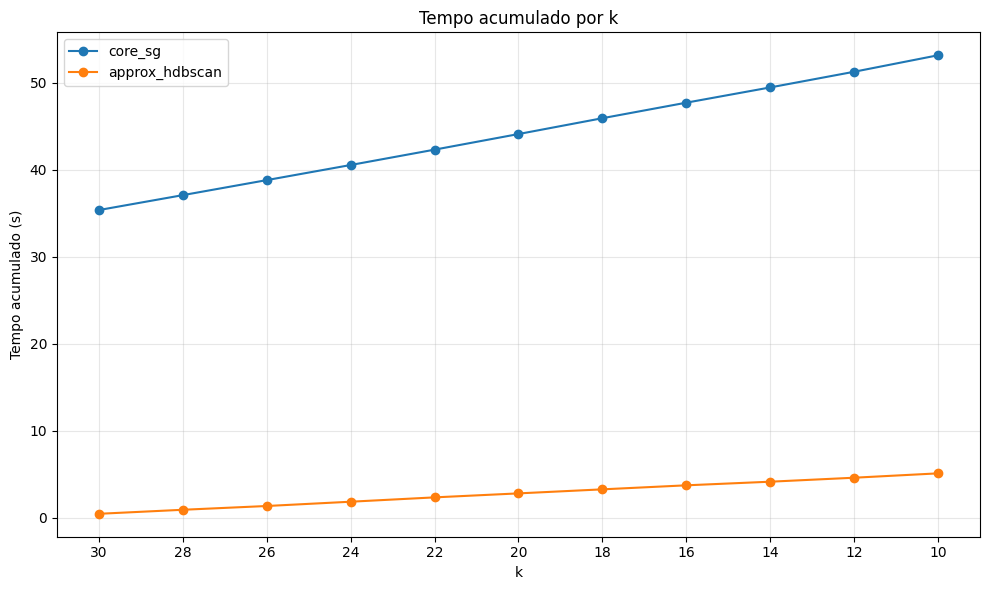

In [8]:
import matplotlib.pyplot as plt

ks = sorted(d.keys(), reverse=True)
x_labels = [str(k) for k in ks]

core_sg_cum = []
approx_hdbscan_cum = []

acc_core_sg = 0.0
acc_approx_hdbscan = 0.0

for k_iter in ks:
    acc_core_sg += d[k_iter]["core_sg"]
    acc_approx_hdbscan += d[k_iter]["approx_hdbscan"]
    core_sg_cum.append(acc_core_sg)
    approx_hdbscan_cum.append(acc_approx_hdbscan)

plt.figure(figsize=(10, 6))
plt.plot(x_labels, core_sg_cum, marker="o", label="core_sg")
plt.plot(x_labels, approx_hdbscan_cum, marker="o", label="approx_hdbscan")

plt.xlabel("k")
plt.ylabel("Tempo acumulado (s)")
plt.title("Tempo acumulado por k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
